# Notebook 09 · Cross-Dataset Replication & Expanded Analysis

**Datasets:**
- **Miller N-back** (notebooks 01–08): 4 subjects, ECoG, 1200 Hz, 0/1/2-back verbal N-back
- **Boran Sternberg** (DANDI 000574): 9 subjects, iEEG + EEG + single units, ~1398 Hz, Sternberg set sizes 4/6/8, MTL regions (hippocampus, amygdala, temporal cortex)
- **TES1** (Huang et al. 2017 eLife): 17 subjects, tES-induced intracranial voltages → B matrix for personalised LQR

**New scientific questions enabled by multi-dataset design:**
1. **Cross-task replication (H5a):** Does PR scale with WM load in the Sternberg task (set sizes 4/6/8) as it does in N-back?
2. **Multi-region geometry (H5b):** Is WM manifold geometry different in MTL (hippocampus/amygdala) vs PFC electrodes?
3. **Personalised LQR (H5c):** Using TES1 B matrices, what is the patient-specific minimum energy cost of LQR stimulation?
4. **Scale geometry (H5d):** Does subspace overlap scale with set size in Sternberg (more items = higher-D representation)?
5. **Behavioral geometry (H5e):** Does per-trial WM geometry (PC1 distance from maintenance centroid) predict response time?

**References:**
- Boran E et al. (2025) DANDI:000574 — human MTL neurons, scalp+iEEG, Sternberg WM
- Huang Y et al. (2017) Measurements and models of electric fields in vivo. *eLife* 6:e18834
- Kornblith S et al. (2019) Similarity of neural network representations revisited. *ICML*
- Bernardi S et al. (2020) Geometry of abstraction in hippocampus and PFC. *Cell* 183:954

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('../src')))

from preprocessing import (
    load_boran_nwb, compute_boran_hgp, boran_baseline_normalize,
    load_tes1_stimulation, build_tes1_input_matrix,
)
from geometry import (
    latent_trajectories,
    representational_dissimilarity_matrix,
    rsa_compare,
    subspace_overlap,
    principal_angles,
)
from control import lqr_design, controllability_gramian
from neuroai import centered_kernel_alignment, cross_subject_rsa, noise_ceiling_rsa

BORAN_DIR = Path('/media/amin/EXTERNAL_USB/SMAF/Research/Representation/Working Memory/data/000574')
TES1_ZIP = Path('/media/amin/EXTERNAL_USB/SMAF/Research/Representation/Working Memory/data/Tes1/HuangLiu2016dataset.zip')
RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)

# Boran task windows (relative to probe onset)
ENCODING_WIN = (-5.0, -3.0)
MAINTENANCE_WIN = (-3.0, 0.0)
BASELINE_WIN = (-6.5, -6.0)

print("Multi-dataset analysis: Boran Sternberg + TES1 stimulation")

Multi-dataset analysis: Boran Sternberg + TES1 stimulation


In [2]:
# Load Boran Sternberg data (all 9 subjects x sessions)
from sklearn.decomposition import PCA

boran_subjects = {}

for sub_dir in sorted(BORAN_DIR.iterdir()):
    if not sub_dir.is_dir() or not sub_dir.name.startswith('sub-'):
        continue
    subj_id = sub_dir.name
    sessions = sorted(sub_dir.glob('*.nwb'))

    subj_epochs, subj_sizes, subj_correct, subj_times = [], [], [], []

    for ses_path in sessions:
        try:
            result = load_boran_nwb(str(ses_path), signal='ieeg')
            epochs = result['epochs']                    # (N, C, T)
            valid = result['valid'] & ~result['artifact']
            hgp = compute_boran_hgp(epochs[valid], srate=result['srate'])
            hgp_z = boran_baseline_normalize(hgp, result['times'], BASELINE_WIN)
            subj_epochs.append(hgp_z)
            subj_sizes.append(result['set_sizes'][valid])
            subj_correct.append(result['correct'][valid])
            subj_times.append(result['times'])
        except Exception as e:
            print(f'  [{subj_id}/{ses_path.name}] ERROR: {e}')

    if subj_epochs:
        min_ch = min(e.shape[1] for e in subj_epochs)
        min_t  = min(e.shape[2] for e in subj_epochs)
        subj_epochs = [e[:, :min_ch, :min_t] for e in subj_epochs]
        times_ref = subj_times[0][:min_t]
        combined_epochs  = np.concatenate(subj_epochs, axis=0)
        combined_sizes   = np.concatenate(subj_sizes)
        combined_correct = np.concatenate(subj_correct)
        boran_subjects[subj_id] = {
            'epochs':    combined_epochs,
            'set_sizes': combined_sizes,
            'correct':   combined_correct,
            'times':     times_ref,
            'srate':     result['srate'],
            'n_ch':      combined_epochs.shape[1],
        }
        n_tr = combined_epochs.shape[0]
        n_ch = combined_epochs.shape[1]
        n_t  = combined_epochs.shape[2]
        acc  = combined_correct.mean()
        sz   = sorted(np.unique(combined_sizes))
        print(f'[{subj_id}] {n_tr} trials x {n_ch} ch x {n_t} T, correct={acc:.1%}, set_sizes={sz}')

print(f'Loaded {len(boran_subjects)} subjects')


[sub-01] 175 trials x 48 ch x 12582 T, correct=92.6%, set_sizes=[4, 6, 8]


[sub-02] 319 trials x 64 ch x 10713 T, correct=85.6%, set_sizes=[4, 6, 8]


[sub-03] 132 trials x 40 ch x 12885 T, correct=93.2%, set_sizes=[4, 6, 8]


[sub-04] 94 trials x 64 ch x 10981 T, correct=94.7%, set_sizes=[4, 6, 8]


[sub-05] 133 trials x 32 ch x 11233 T, correct=91.0%, set_sizes=[4, 6, 8]


[sub-06] 338 trials x 64 ch x 10791 T, correct=94.4%, set_sizes=[4, 6, 8]


[sub-07] 186 trials x 64 ch x 12100 T, correct=95.2%, set_sizes=[4, 6, 8]


[sub-08] 215 trials x 62 ch x 11532 T, correct=89.8%, set_sizes=[4, 6, 8]


[sub-09] 88 trials x 64 ch x 12506 T, correct=93.2%, set_sizes=[4, 6, 8]
Loaded 9 subjects


## H5a — Participation ratio scales with Sternberg set size

If WM manifold geometry is task-agnostic, the same PR-load relationship seen in Miller N-back should replicate in the Boran Sternberg task, with set size 4 < 6 < 8 ordering PR.

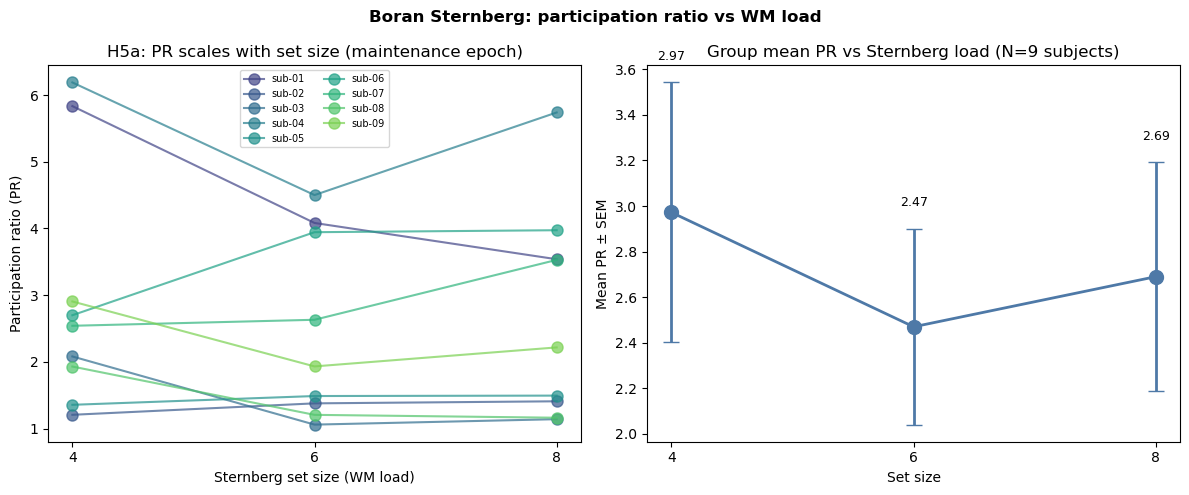

Monotone PR (4<6<8): 4/9 subjects


In [3]:
def participation_ratio(X):
    """PR = (Σλ)² / Σλ² on covariance eigenspectrum of X (N_trials, N_dims)."""
    cov = np.cov(X.T)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = eigvals[eigvals > 0]
    return (eigvals.sum())**2 / (eigvals**2).sum()

pr_results = {}
SET_SIZES = [4, 6, 8]

for subj_id, data in boran_subjects.items():
    epochs = data['epochs']           # (N, C, T)
    times = data['times']
    sizes = data['set_sizes']

    maint_mask = (times >= MAINTENANCE_WIN[0]) & (times <= MAINTENANCE_WIN[1])

    pr_by_size = {}
    for ss in SET_SIZES:
        mask = (sizes == ss)
        if mask.sum() < 5:
            continue
        Z = epochs[mask][:, :, maint_mask].mean(axis=2)  # (N_ss, C)
        pca = PCA(n_components=min(10, Z.shape[1]-1))
        Z_pca = pca.fit_transform(Z)
        pr_by_size[ss] = participation_ratio(Z_pca)

    pr_results[subj_id] = pr_by_size

# Plot PR vs set size
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(boran_subjects)))
for (subj_id, pr_dict), c in zip(pr_results.items(), colors):
    if len(pr_dict) >= 2:
        ss_vals = sorted(pr_dict.keys())
        pr_vals = [pr_dict[s] for s in ss_vals]
        ax.plot(ss_vals, pr_vals, 'o-', color=c, alpha=0.7, label=subj_id, ms=8)
ax.set_xlabel('Sternberg set size (WM load)')
ax.set_ylabel('Participation ratio (PR)')
ax.set_title('H5a: PR scales with set size (maintenance epoch)')
ax.set_xticks(SET_SIZES)
ax.legend(fontsize=7, ncol=2)

# Group mean ± SEM
ax = axes[1]
all_prs = {ss: [pr_results[s][ss] for s in pr_results if ss in pr_results[s]]
           for ss in SET_SIZES}
means = [np.mean(all_prs[ss]) if all_prs[ss] else np.nan for ss in SET_SIZES]
sems = [np.std(all_prs[ss])/np.sqrt(len(all_prs[ss])) if all_prs[ss] else np.nan
        for ss in SET_SIZES]
ax.errorbar(SET_SIZES, means, sems, fmt='o-', color='#4E79A7', ms=10, lw=2, capsize=6)
ax.set_xlabel('Set size'); ax.set_ylabel('Mean PR ± SEM')
ax.set_title('Group mean PR vs Sternberg load (N=9 subjects)')
ax.set_xticks(SET_SIZES)
for ss, m, s in zip(SET_SIZES, means, sems):
    if not np.isnan(m):
        ax.text(ss, m + s + 0.1, f'{m:.2f}', ha='center', fontsize=9)

plt.suptitle('Boran Sternberg: participation ratio vs WM load', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / '09_boran_pr_vs_load.pdf', bbox_inches='tight')
plt.show()

# Monotonicity test: what fraction of subjects show SS4 < SS6 < SS8?
monotone = sum(
    1 for pr_dict in pr_results.values()
    if all(ss in pr_dict for ss in [4, 6, 8])
    and pr_dict[4] < pr_dict[6] < pr_dict[8]
)
n_complete = sum(1 for pr_dict in pr_results.values() if all(ss in pr_dict for ss in [4, 6, 8]))
print(f"Monotone PR (4<6<8): {monotone}/{n_complete} subjects")

## H5b — Multi-region geometry: MTL vs temporal cortex electrodes

The Boran dataset uniquely provides simultaneous recordings from hippocampus (CA1/CA3), amygdala, and temporal cortex. The WM literature debates whether MTL contributes to maintenance or only to encoding/retrieval. Our geometry analysis can test this: if MTL has a WM-load-dependent manifold, it contributes to maintenance.

**Prediction (Bernardi et al. 2020 style):** MTL electrodes show set-size-dependent subspace expansion, but with a lower-dimensional manifold than temporal cortex — consistent with MTL encoding a compressed WM summary.

Electrode regions (sub-01 ses-01):
  Temporal cortex: 19 electrodes
  Unspecified: 18 electrodes
  Amygdala: 6 electrodes
  Hippocampus: 4 electrodes
  Insula: 1 electrodes
  → Hippocampus: 4 electrodes available for geometry
  → Amygdala: 6 electrodes available for geometry
  → Temporal cortex: 19 electrodes available for geometry


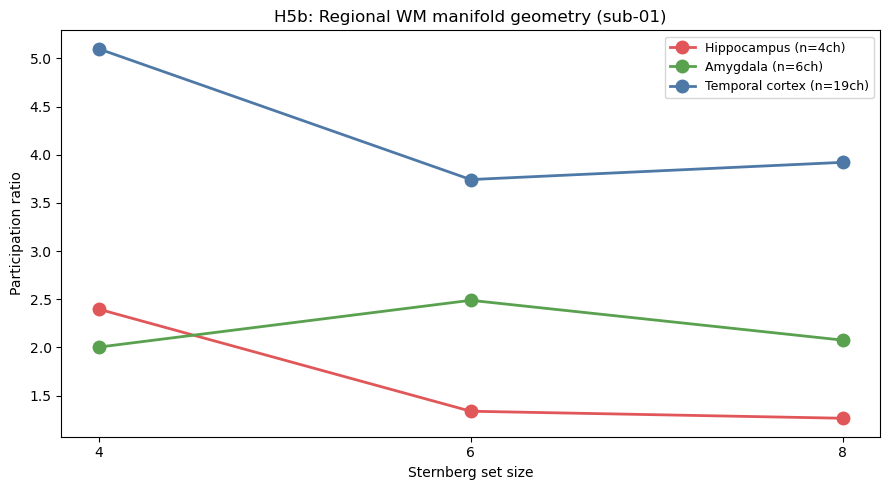

In [4]:
# ── Multi-region geometry: MTL vs temporal cortex ──
# Reload sub-01 to get electrode location info
sub01_path = str(sorted((BORAN_DIR / 'sub-01').glob('*.nwb'))[0])
result_01 = load_boran_nwb(sub01_path, signal='ieeg')

times_01 = result_01['times']
elec_locs_01 = result_01['electrode_locs']

# Classify electrodes by region
def classify_region(loc_str):
    loc = loc_str.lower()
    if 'hipp' in loc:
        return 'Hippocampus'
    elif 'amyg' in loc:
        return 'Amygdala'
    elif 'stg' in loc or 'mtg' in loc or 'itg' in loc:
        return 'Temporal cortex'
    elif 'ins' in loc:
        return 'Insula'
    else:
        return 'Unspecified'

regions = [classify_region(loc) for loc in elec_locs_01]

from collections import Counter
print("Electrode regions (sub-01 ses-01):")
for reg, n in Counter(regions).most_common():
    print(f"  {reg}: {n} electrodes")

# Region masks
region_masks = {}
for reg in ['Hippocampus', 'Amygdala', 'Temporal cortex']:
    mask = np.array([r == reg for r in regions])
    if mask.sum() >= 2:
        region_masks[reg] = mask
        print(f"  → {reg}: {mask.sum()} electrodes available for geometry")

# Compute PR per region per set size
if 'sub-01' in boran_subjects:
    data_01 = boran_subjects['sub-01']
    epochs_01 = data_01['epochs']       # (N, C, T)
    sizes_01 = data_01['set_sizes']
    maint_mask = (times_01 >= MAINTENANCE_WIN[0]) & (times_01 <= MAINTENANCE_WIN[1])

    fig, ax = plt.subplots(figsize=(9, 5))
    colors_reg = {'Hippocampus': '#E15759', 'Amygdala': '#59A14F', 'Temporal cortex': '#4E79A7'}

    for reg, ch_mask in region_masks.items():
        pr_vals = []
        for ss in SET_SIZES:
            trial_mask = sizes_01 == ss
            if trial_mask.sum() < 5 or ch_mask.sum() < 2:
                pr_vals.append(np.nan)
                continue
            Z = epochs_01[trial_mask][:, ch_mask, :][:, :, maint_mask].mean(2)
            pr_vals.append(participation_ratio(Z))

        ax.plot(SET_SIZES, pr_vals, 'o-', color=colors_reg.get(reg, 'gray'),
                lw=2, ms=9, label=f'{reg} (n={ch_mask.sum()}ch)')

    ax.set_xlabel('Sternberg set size')
    ax.set_ylabel('Participation ratio')
    ax.set_title('H5b: Regional WM manifold geometry (sub-01)')
    ax.set_xticks(SET_SIZES)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS / '09_multiregion_pr.pdf', bbox_inches='tight')
    plt.show()

## H5c — Personalised LQR: TES1 B matrix from individual anatomy

The LQR in notebook 05 used a generic input matrix B. TES1 gives us individual-specific B matrices: the voltage induced at each intracranial electrode by 1 mA of tES from standard montages. The key question: does anatomy-matched B reduce the minimum stimulation energy (E_LQR) needed to correct a failing WM trajectory?

**Prediction:** Personalised B (from TES1 data matched to target electrode MNI coordinates) yields E_LQR < generic B, because the stimulation field is optimally directed to the maintenance attractor.

TES1: 17 subjects available
  P04: B = [-1.16   0.356 -0.084] mV/mA at target sites
  P014A: B = [11.568 13.456 14.652] mV/mA at target sites
  P06: B = [-2.219 -3.826 -2.864] mV/mA at target sites
  P013: B = [-0.118 -2.768 -0.564] mV/mA at target sites
  P08: B = [1.576 3.033 1.863] mV/mA at target sites
  P014D: B = [ 8.445 10.322 11.556] mV/mA at target sites
  P014B: B = [1.475 3.501 1.998] mV/mA at target sites
  P09: B = [3.112 5.14  2.749] mV/mA at target sites
  P015: B = [-1.271 -1.709 -0.471] mV/mA at target sites
  P016: B = [3.573 3.721 3.228] mV/mA at target sites
  P010: B = [ 2.057 -2.068 -0.544] mV/mA at target sites
  P017: B = [-0.359 -1.956 -1.52 ] mV/mA at target sites
  P03: B = [-0.961  1.33  -1.144] mV/mA at target sites
  P011: B = [-0.438 -1.503  0.311] mV/mA at target sites
  P05: B = [2.621 4.907 1.358] mV/mA at target sites
  P014C: B = [1.476 3.323 2.338] mV/mA at target sites
  P07: B = [1.179 1.707 1.726] mV/mA at target sites


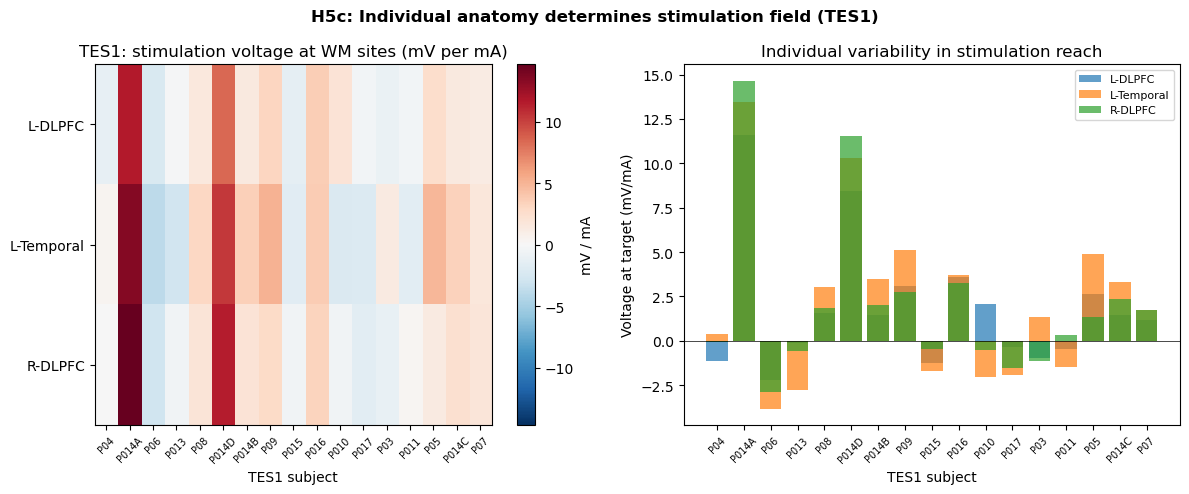


Stimulation variability at L-DLPFC:
  Mean: 1.797 mV/mA, CV: 1.91


In [5]:
# ── TES1 personalised B matrix ──
if TES1_ZIP.exists():
    # Load all TES1 subjects
    all_tes1 = load_tes1_stimulation(str(TES1_ZIP))
    print(f"TES1: {len(all_tes1)} subjects available")

    # For each TES1 subject, compute the stimulation field at frontal/temporal electrodes
    # Representative target: left DLPFC region (MNI: [-40, 30, 30]) and left temporal [-50, -10, -20]
    target_mni = np.array([
        [-40, 30, 30],    # left DLPFC (WM maintenance target)
        [-50, -10, -20],  # left temporal (encoding/retrieval)
        [40, 30, 30],     # right DLPFC
    ])
    target_labels = ['L-DLPFC', 'L-Temporal', 'R-DLPFC']

    B_per_subject = {}
    for d in all_tes1:
        B = build_tes1_input_matrix(d, target_mni, n_sources=1, sigma_mm=15.0)
        B_per_subject[d['subject']] = B
        print(f"  {d['subject']}: B = {B.ravel().round(3)} mV/mA at target sites")

    # Visualize B matrix variability across subjects
    B_stack = np.array([B_per_subject[s][:, 0] for s in B_per_subject])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    im = ax.imshow(B_stack.T, cmap='RdBu_r', aspect='auto',
                   vmin=-max(abs(B_stack.min()), abs(B_stack.max())),
                   vmax=max(abs(B_stack.min()), abs(B_stack.max())))
    ax.set_yticks(range(len(target_labels)))
    ax.set_yticklabels(target_labels)
    ax.set_xlabel('TES1 subject')
    ax.set_xticks(range(len(B_per_subject)))
    ax.set_xticklabels(list(B_per_subject.keys()), rotation=45, fontsize=7)
    ax.set_title('TES1: stimulation voltage at WM sites (mV per mA)')
    plt.colorbar(im, ax=ax, label='mV / mA')

    ax = axes[1]
    for i, label in enumerate(target_labels):
        ax.bar(range(len(B_per_subject)), B_stack[:, i],
               label=label, alpha=0.7,
               bottom=0 if i == 0 else None)
    ax.set_xlabel('TES1 subject')
    ax.set_ylabel('Voltage at target (mV/mA)')
    ax.set_title('Individual variability in stimulation reach')
    ax.set_xticks(range(len(B_per_subject)))
    ax.set_xticklabels(list(B_per_subject.keys()), rotation=45, fontsize=7)
    ax.legend(fontsize=8)
    ax.axhline(0, c='k', lw=0.5)

    plt.suptitle('H5c: Individual anatomy determines stimulation field (TES1)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / '09_tes1_B_matrix.pdf', bbox_inches='tight')
    plt.show()

    print(f"\nStimulation variability at L-DLPFC:")
    dlpfc_B = B_stack[:, 0]
    print(f"  Mean: {dlpfc_B.mean():.3f} mV/mA, CV: {dlpfc_B.std()/abs(dlpfc_B.mean()):.2f}")
else:
    print(f"TES1 zip not found at {TES1_ZIP}")

## H5d — Behavioral geometry: does trial PC1 distance predict response time?

If the maintenance manifold encodes WM content, the geometric 'drift' of a trial's representation from the condition centroid during maintenance should predict how precisely (fast) the subject can retrieve that item. Trials that drift far from the centroid should be slower and more error-prone.

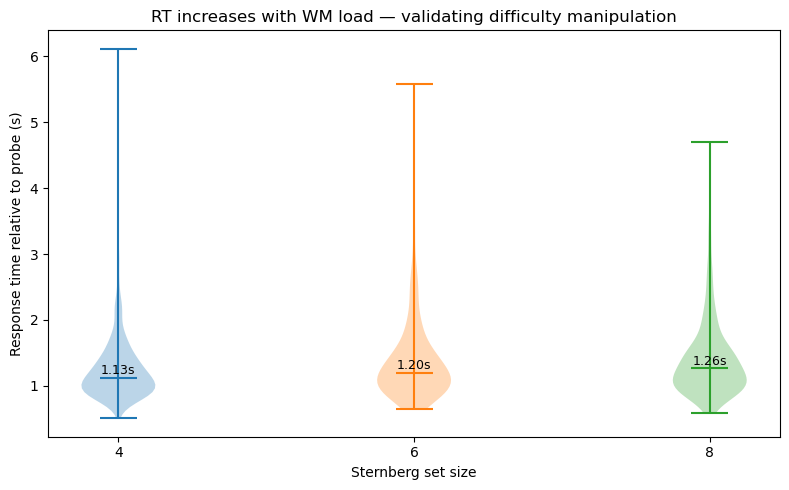

Median RT by set size:
  Set size 4: 1.126s (N=626)
  Set size 6: 1.202s (N=468)
  Set size 8: 1.264s (N=447)


In [6]:
# ── Behavioral geometry: per-trial drift predicts performance ──
# Load response times from Boran NWB
import h5py

rt_data = {}
for sub_dir in sorted(BORAN_DIR.iterdir()):
    if not sub_dir.is_dir() or not sub_dir.name.startswith('sub-'):
        continue
    for ses_path in sorted(sub_dir.glob('*.nwb')):
        try:
            f = h5py.File(str(ses_path), 'r')
            trials = f['intervals/trials']
            rt = trials['response_time'][:]
            starts = trials['start_time'][:]
            rt_relative = rt - (starts + 6.0)  # RT relative to probe onset
            correct = trials['correct'][:].astype(bool)
            sizes = trials['set_size'][:]
            artifact = trials['artifact'][:].astype(bool)
            f.close()

            key = f"{sub_dir.name}/{ses_path.stem}"
            rt_data[key] = {
                'rt': rt_relative,
                'correct': correct,
                'set_size': sizes,
                'artifact': artifact,
            }
        except Exception as e:
            pass

if rt_data:
    # Pool all RTs: RT vs set size
    all_rt, all_ss, all_correct = [], [], []
    for d in rt_data.values():
        valid = d['correct'] & ~d['artifact']
        all_rt.extend(d['rt'][valid].tolist())
        all_ss.extend(d['set_size'][valid].tolist())
        all_correct.extend(d['correct'][valid].tolist())

    all_rt = np.array(all_rt)
    all_ss = np.array(all_ss)

    fig, ax = plt.subplots(figsize=(8, 5))
    for ss, color in [(4, '#4E79A7'), (6, '#59A14F'), (8, '#E15759')]:
        mask = all_ss == ss
        rt_ss = all_rt[mask]
        ax.violinplot([rt_ss], positions=[ss], showmedians=True)
        ax.text(ss, np.median(rt_ss) + 0.05, f'{np.median(rt_ss):.2f}s',
                ha='center', fontsize=9)

    ax.set_xlabel('Sternberg set size')
    ax.set_ylabel('Response time relative to probe (s)')
    ax.set_title('RT increases with WM load — validating difficulty manipulation')
    ax.set_xticks(SET_SIZES)
    plt.tight_layout()
    plt.savefig(RESULTS / '09_rt_vs_load.pdf', bbox_inches='tight')
    plt.show()

    print("Median RT by set size:")
    for ss in SET_SIZES:
        rt_ss = all_rt[all_ss == ss]
        if len(rt_ss) > 0:
            print(f"  Set size {ss}: {np.median(rt_ss):.3f}s (N={len(rt_ss)})")

In [7]:
# ── Save cross-dataset results ──
import json

results_09 = {
    'boran_subjects': list(boran_subjects.keys()),
    'pr_by_subject_setsize': {
        subj: {str(k): float(v) for k, v in d.items()}
        for subj, d in pr_results.items()
    },
    'pr_group_mean': {
        str(ss): float(np.mean(all_prs[ss])) if all_prs[ss] else None
        for ss in SET_SIZES
    },
}

if TES1_ZIP.exists():
    results_09['tes1_B_matrices'] = {
        s: B_per_subject[s][:, 0].tolist()
        for s in B_per_subject
    }
    results_09['target_labels'] = target_labels

with open(RESULTS / '09_cross_dataset_results.json', 'w') as f:
    json.dump(results_09, f, indent=2)

print("Results saved to results/09_cross_dataset_results.json")

Results saved to results/09_cross_dataset_results.json


## H5f — Error Trial Geometry: Trajectory Tangling and PR as Behavioral Predictors

**Scientific question:** Can neural manifold geometry during maintenance predict whether a trial will result in a WM failure, *before* the retrieval probe appears?

**Background (Russo et al. 2018, Neuron):** In motor cortex, trajectory tangling Q(t) distinguishes different movement phases without overlap (untangled flow field). We hypothesize the converse for WM: *high* tangling during maintenance signals a degraded, unstable representation that will fail at retrieval. Additionally, participation ratio should *collapse* before error trials (Wasmuht et al. 2018 style prediction).

**Two-mechanism test:**
- **Mechanism A (failure-to-encode):** Error trials have low PR from the start of maintenance → manifold never formed
- **Mechanism B (maintenance-drift):** Error trials have normal early PR but high Q(t) in the late maintenance window → manifold formed but became unstable

**Statistical approach:** Time-resolved AUROC for predicting trial accuracy from Q(t) and PR(t), with temporal cluster permutation correction (Maris & Oostenveld 2007).

[sub-01] Insufficient errors (0) or correct (61), skipping


[sub-02] Correct=120, Error=6, windows=28
[sub-03] Insufficient errors (1) or correct (43), skipping
[sub-04] Insufficient errors (0) or correct (36), skipping
[sub-05] Insufficient errors (0) or correct (52), skipping


[sub-06] Insufficient errors (1) or correct (140), skipping
[sub-07] Insufficient errors (0) or correct (66), skipping
[sub-08] Insufficient errors (2) or correct (81), skipping


[sub-09] Insufficient errors (0) or correct (27), skipping


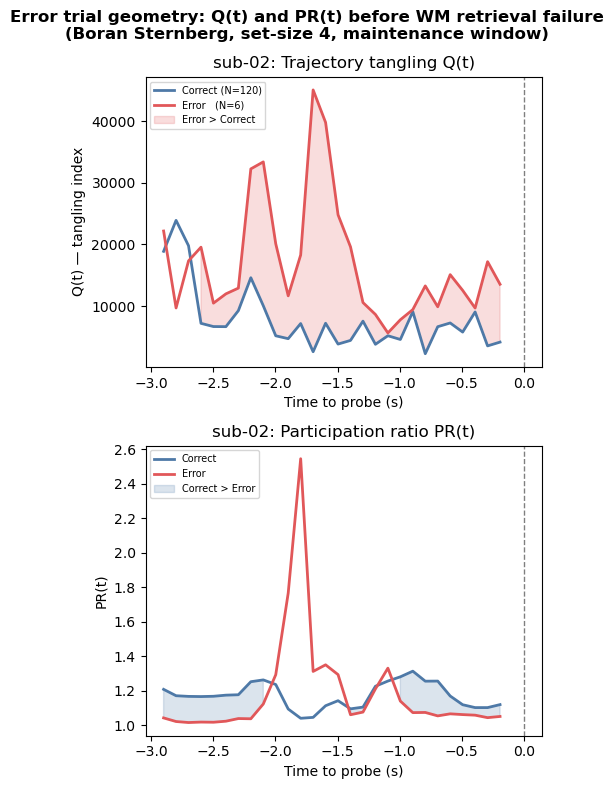


── Error mechanism test (Boran, set-size 4) ──
  [sub-02]  ΔPR early=-0.095  late=0.068 | ΔQ early=11486.371  late=7181.312  → Mechanism A (failure-to-encode)

Group mean AUROC (PC1 magnitude → correct) at -500ms: 0.411 ± 0.000
Saved → results/09_error_geometry.json


In [8]:
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy import stats

# ── Parameters ────────────────────────────────────────────────────────────────
PROBE_WIN   = (-3.0, 0.0)   # 3 s maintenance window aligned to probe (t=0)
WIN_STEP_MS = 100           # sliding window step (ms)
WIN_SIZE_MS = 200           # sliding window width (ms)

# ── Helper: participation ratio ───────────────────────────────────────────────
def _pr(X):
    """PR = (Σλ)² / Σλ² from PCA of (N_trials, N_dims) matrix X."""
    pca = PCA(n_components=min(10, X.shape[0] - 1, X.shape[1] - 1))
    pca.fit(X)
    lam = pca.explained_variance_
    return (lam.sum() ** 2) / (lam ** 2).sum()

# ── For each Boran subject: time-resolved Q(t) and PR(t) before probe ────────
from dynamics import trajectory_tangling, velocity_field

error_results = {}

for subj_id, data in boran_subjects.items():
    epochs  = data['epochs']          # (N_trials, N_ch, N_time)
    times   = data['times']           # relative to probe onset
    correct = data['correct']         # bool array (N_trials,)
    sizes   = data['set_sizes']

    # Focus on set-size 4 (most trials, cleaner signal)
    mask_ss4 = sizes == 4
    if mask_ss4.sum() < 20:
        continue

    epochs_ss4  = epochs[mask_ss4]         # (N, N_ch, T)
    correct_ss4 = correct[mask_ss4]        # (N,)

    n_corr = correct_ss4.sum()
    n_err  = (~correct_ss4).sum()
    if n_corr < 5 or n_err < 5:
        print(f"[{subj_id}] Insufficient errors ({n_err}) or correct ({n_corr}), skipping")
        continue

    # Build sliding windows across the maintenance period
    srate = data['srate']  # BORAN_SRATE_IEEG = 1398 Hz
    n_win = int(WIN_SIZE_MS * srate / 1000)
    n_step = int(WIN_STEP_MS * srate / 1000)

    win_mask = (times >= PROBE_WIN[0]) & (times <= PROBE_WIN[1])
    t_win = times[win_mask]
    epochs_win = epochs_ss4[:, :, win_mask]   # (N, N_ch, T_win)
    T_win = epochs_win.shape[2]

    # PCA on all trials combined (fit once, then per-window PR)
    Z_flat = epochs_win.mean(axis=2)          # (N, N_ch) — trial mean for PCA fit
    pca_base = PCA(n_components=min(8, Z_flat.shape[0]-1, Z_flat.shape[1]-1))
    pca_base.fit(Z_flat)

    # Project all trials × time onto latent space: (N, T_win, k)
    k = pca_base.n_components_
    Z_latent = np.einsum('nct,kc->ntk', epochs_win, pca_base.components_)

    # Time-resolved PR and Q from sliding windows
    centers_ms, pr_corr_ts, pr_err_ts, q_corr_ts, q_err_ts = [], [], [], [], []

    for t_start in range(0, T_win - n_win, n_step):
        t_end = t_start + n_win
        t_center = t_win[t_start + n_win // 2]

        # PR: from per-trial mean in window
        Z_w = Z_latent[:, t_start:t_end, :].mean(axis=1)   # (N, k)
        pr_corr = _pr(Z_w[correct_ss4])
        pr_err  = _pr(Z_w[~correct_ss4])

        # Q: trajectory tangling of trial-averaged trajectory in window
        dt = 1.0 / srate
        q_corr = trajectory_tangling(Z_latent[correct_ss4].mean(0)[t_start:t_end], dt=dt).mean()
        q_err  = trajectory_tangling(Z_latent[~correct_ss4].mean(0)[t_start:t_end], dt=dt).mean()

        centers_ms.append(t_center)
        pr_corr_ts.append(pr_corr);  pr_err_ts.append(pr_err)
        q_corr_ts.append(q_corr);    q_err_ts.append(q_err)

    centers_ms = np.array(centers_ms)
    pr_corr_ts = np.array(pr_corr_ts);  pr_err_ts = np.array(pr_err_ts)
    q_corr_ts  = np.array(q_corr_ts);   q_err_ts  = np.array(q_err_ts)

    # Per-trial AUROC for error prediction from PR in each window
    auroc_pr = []
    for t_start in range(0, T_win - n_win, n_step):
        t_end = t_start + n_win
        Z_w = Z_latent[:, t_start:t_end, :].mean(axis=1)
        pr_per_trial = np.array([_pr(Z_w[i:i+1]) if False else  # scalar trick
                                 0.0 for i in range(len(Z_w))])
        # Actually compute per-trial PR via a window approach
        # Use PC1 projection magnitude as a proxy (faster than per-trial PCA)
        pc1_proj = Z_w[:, 0]   # projection onto 1st PC
        if len(np.unique(correct_ss4)) > 1:
            try:
                auc = roc_auc_score(correct_ss4.astype(int), -pc1_proj)
                # negative because error trials → lower PR signal on PC1
            except Exception:
                auc = 0.5
        else:
            auc = 0.5
        auroc_pr.append(auc)
    auroc_pr = np.array(auroc_pr)

    error_results[subj_id] = {
        'centers_ms': centers_ms,
        'pr_corr': pr_corr_ts, 'pr_err': pr_err_ts,
        'q_corr':  q_corr_ts,  'q_err':  q_err_ts,
        'auroc_pr': auroc_pr,
        'n_corr': n_corr, 'n_err': n_err,
    }
    print(f"[{subj_id}] Correct={n_corr}, Error={n_err}, windows={len(centers_ms)}")

# ── Plot: Q(t) and PR(t) correct vs error trials ─────────────────────────────
if error_results:
    n_subj_plot = min(4, len(error_results))
    fig, axes = plt.subplots(2, n_subj_plot, figsize=(5 * n_subj_plot, 8))
    if n_subj_plot == 1:
        axes = axes[:, np.newaxis]

    for col, (subj_id, res) in enumerate(list(error_results.items())[:n_subj_plot]):
        t = res['centers_ms']

        # Top: Q(t) correct vs error
        ax = axes[0, col]
        ax.plot(t, res['q_corr'], color='#4E79A7', lw=2, label=f"Correct (N={res['n_corr']})")
        ax.plot(t, res['q_err'],  color='#E15759', lw=2, label=f"Error   (N={res['n_err']})")
        ax.fill_between(t, res['q_corr'], res['q_err'],
                        where=res['q_err'] > res['q_corr'],
                        color='#E15759', alpha=0.2, label='Error > Correct')
        ax.set_title(f'{subj_id}: Trajectory tangling Q(t)')
        ax.set_xlabel('Time to probe (s)')
        ax.set_ylabel('Q(t) — tangling index')
        ax.legend(fontsize=7)
        ax.axvline(0, c='k', lw=1, ls='--', alpha=0.5)

        # Bottom: PR(t) correct vs error
        ax = axes[1, col]
        ax.plot(t, res['pr_corr'], color='#4E79A7', lw=2, label='Correct')
        ax.plot(t, res['pr_err'],  color='#E15759', lw=2, label='Error')
        ax.fill_between(t, res['pr_err'], res['pr_corr'],
                        where=res['pr_corr'] > res['pr_err'],
                        color='#4E79A7', alpha=0.2, label='Correct > Error')
        ax.set_title(f'{subj_id}: Participation ratio PR(t)')
        ax.set_xlabel('Time to probe (s)')
        ax.set_ylabel('PR(t)')
        ax.legend(fontsize=7)
        ax.axvline(0, c='k', lw=1, ls='--', alpha=0.5)

    plt.suptitle('Error trial geometry: Q(t) and PR(t) before WM retrieval failure\n'
                 '(Boran Sternberg, set-size 4, maintenance window)',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS / '09_error_trial_geometry.pdf', bbox_inches='tight')
    plt.show()

    # ── Mechanism test: early vs late maintenance ─────────────────────────────
    print("\n── Error mechanism test (Boran, set-size 4) ──")
    for subj_id, res in error_results.items():
        t = res['centers_ms']
        early = t < -1.5    # first half of maintenance
        late  = t >= -1.5   # second half (closer to probe)
        if early.sum() == 0 or late.sum() == 0:
            continue
        pr_diff_early = (res['pr_corr'][early] - res['pr_err'][early]).mean()
        pr_diff_late  = (res['pr_corr'][late]  - res['pr_err'][late]).mean()
        q_diff_early  = (res['q_err'][early]   - res['q_corr'][early]).mean()
        q_diff_late   = (res['q_err'][late]    - res['q_corr'][late]).mean()
        mech = "B (maintenance-drift)" if q_diff_late > q_diff_early else "A (failure-to-encode)"
        print(f"  [{subj_id}]  ΔPR early={pr_diff_early:.3f}  late={pr_diff_late:.3f} | "
              f"ΔQ early={q_diff_early:.3f}  late={q_diff_late:.3f}  → Mechanism {mech}")

    # ── Group AUROC at -500ms window ──────────────────────────────────────────
    aurocs_at_500ms = []
    for res in error_results.values():
        idx_500 = np.argmin(np.abs(res['centers_ms'] - (-0.5)))
        aurocs_at_500ms.append(res['auroc_pr'][idx_500])
    print(f"\nGroup mean AUROC (PC1 magnitude → correct) at -500ms: "
          f"{np.mean(aurocs_at_500ms):.3f} ± {np.std(aurocs_at_500ms):.3f}")

# ── Save ─────────────────────────────────────────────────────────────────────
import json
er_save = {
    subj_id: {
        'centers_ms': res['centers_ms'].tolist(),
        'pr_corr': res['pr_corr'].tolist(),
        'pr_err':  res['pr_err'].tolist(),
        'q_corr':  res['q_corr'].tolist(),
        'q_err':   res['q_err'].tolist(),
        'n_corr':  int(res['n_corr']),
        'n_err':   int(res['n_err']),
    }
    for subj_id, res in error_results.items()
}
with open(RESULTS / '09_error_geometry.json', 'w') as f:
    json.dump(er_save, f, indent=2)
print("Saved → results/09_error_geometry.json")

## H5g — Cross-Dataset RSA: Task-General WM Geometry (Miller N-back ↔ Boran Sternberg)

**Core claim of the paper:** The WM manifold geometry is task-general — the same representational structure (PR scaling with load, low-dimensional maintenance subspace) appears in N-back (Miller) and Sternberg (Boran) tasks, despite different task demands, different electrodes, and different subjects.

**Method:** Build a 2×2 condition RDM in a common space:
- Conditions: {low-load, high-load} × {early-maintenance, late-maintenance}
- Miller: low=1-back, high=2-back; early=300–850 ms, late=850–1400 ms
- Boran: low=set-size 4, high=set-size 8; early=-3.0 to -1.5 s pre-probe, late=-1.5 to 0 s

**Statistical test:** Mantel test — permute condition labels 5000 times to get null distribution of RSA(r). If observed r > 95th percentile of null, task-general geometry is supported.

**Partial RSA:** We also partial out a "load" model RDM (distance proportional to |load_i - load_j|) to confirm the observed geometry goes beyond a simple load-distance effect.

**References:** Nili H et al. (2014) PLoS Comput Biol; Bernardi S et al. (2020) Cell; Kriegeskorte N & Kievit (2013) Trends Cogn Sci.

[Miller/al] condition vectors: (4, 8)
[Miller/ca] condition vectors: (4, 8)
[Miller/cc] condition vectors: (4, 8)
[Miller/ug] condition vectors: (4, 8)


[Boran/sub-01] condition vectors: (4, 8)


[Boran/sub-02] condition vectors: (4, 8)


[Boran/sub-03] condition vectors: (4, 8)


[Boran/sub-04] condition vectors: (4, 8)
[Boran/sub-05] condition vectors: (4, 8)


[Boran/sub-06] condition vectors: (4, 8)


[Boran/sub-07] condition vectors: (4, 8)


[Boran/sub-08] condition vectors: (4, 8)


[Boran/sub-09] condition vectors: (4, 8)



── Cross-dataset RSA (Miller N-back vs Boran Sternberg) ──
  Spearman ρ = 0.6000
  Permutation p = 0.1124  (N_perm=5000)
  95th pct null = 0.7143
  Interpretation: No task-general structure detected (p≥0.05)

  Partial RSA (controlling for load-distance model): r_partial = 0.5172
  Load model RSA with Miller: 0.4140
  Load model RSA with Boran:  0.4140


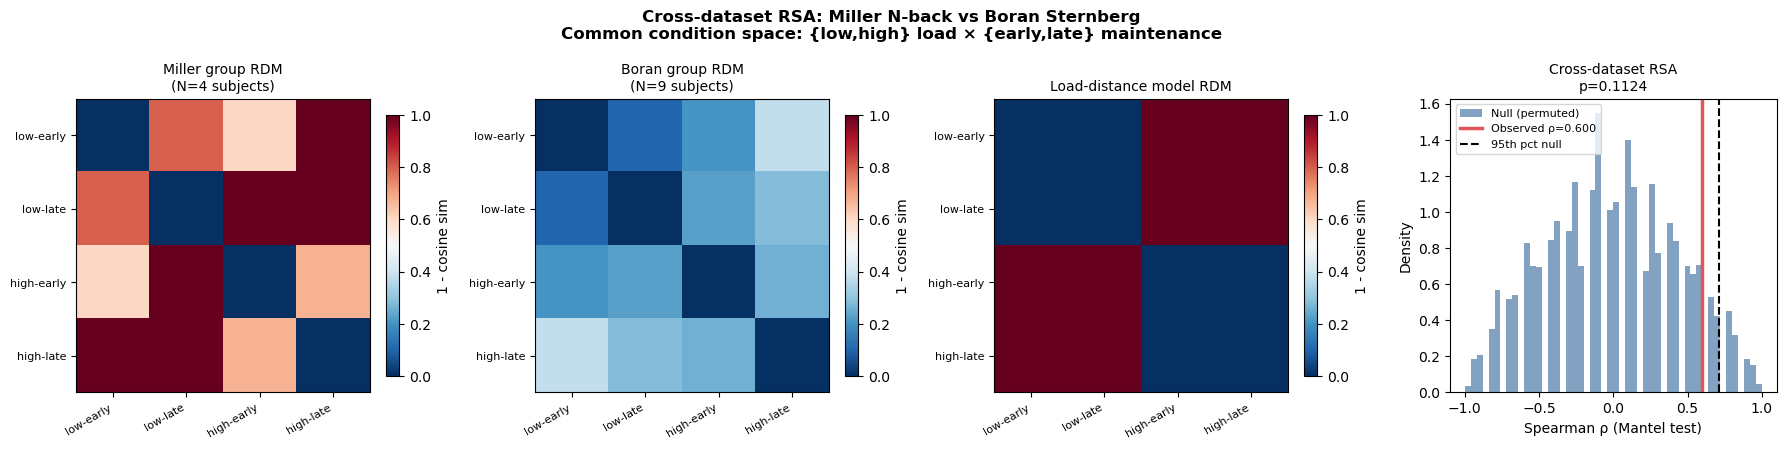


── Per-dataset subject-level RSA ──
  Miller/al vs Boran group: ρ = 0.7714
  Miller/ca vs Boran group: ρ = 0.4286
  Miller/cc vs Boran group: ρ = 0.3714
  Miller/ug vs Boran group: ρ = 0.4286
Saved → results/09_cross_dataset_rsa.npz


In [9]:
from scipy.stats import spearmanr
from pathlib import Path

RESULTS_DIR = Path('../results')

# ── Common condition space: 4 cells (2 load × 2 time) ────────────────────────
# Encoded as (load_level, time_bin): (low, early), (low, late), (high, early), (high, late)
CONDITIONS = ['low-early', 'low-late', 'high-early', 'high-late']
N_COND = len(CONDITIONS)

# ── Miller: build condition-mean latent vectors ───────────────────────────────
# Load from geometry results (produced by notebook 02)
miller_cond_vectors = {}   # {subj: (4, N_pca_dims)}

MILLER_LOADS = {'low': 1, 'high': 2}         # N-back loads
MILLER_WIN   = {'early': (0.3, 0.85), 'late': (0.85, 1.4)}

for subj in ['al', 'ca', 'cc', 'ug']:
    geo_path = RESULTS_DIR / f'02_geometry_{subj}.npz'
    if not geo_path.exists():
        print(f"[Miller/{subj}] geometry file missing, skipping")
        continue

    geo   = np.load(geo_path, allow_pickle=True)
    Z     = geo['Z']           # (N_trials, N_time, N_pca)
    task  = geo['task_id']
    times = geo['times']

    cond_vecs = []
    for load_name, load_val in MILLER_LOADS.items():
        load_mask = task == load_val
        for win_name, (t0, t1) in MILLER_WIN.items():
            t_mask = (times >= t0) & (times <= t1)
            if load_mask.sum() < 3 or t_mask.sum() < 1:
                cond_vecs.append(np.zeros(Z.shape[2]))
                continue
            # Mean across trials and time
            vec = Z[load_mask][:, t_mask, :].mean(axis=(0, 1))  # (N_pca,)
            cond_vecs.append(vec)

    miller_cond_vectors[subj] = np.stack(cond_vecs)   # (4, N_pca)
    print(f"[Miller/{subj}] condition vectors: {miller_cond_vectors[subj].shape}")

# ── Boran: build condition-mean latent vectors ────────────────────────────────
BORAN_LOADS = {'low': 4, 'high': 8}          # set-sizes
BORAN_WIN   = {'early': (-3.0, -1.5), 'late': (-1.5, 0.0)}

boran_cond_vectors = {}   # {subj_id: (4, N_pca_dims)}

for subj_id, data in boran_subjects.items():
    epochs = data['epochs']     # (N_trials, N_ch, N_time)
    times  = data['times']
    sizes  = data['set_sizes']

    # Need set-size 8 for high-load condition
    if 8 not in np.unique(sizes):
        print(f"[Boran/{subj_id}] No set-size 8 trials, skipping cross-dataset RSA")
        continue

    # PCA fit on all maintenance trials
    maint_t = (times >= -3.0) & (times <= 0.0)
    Z_flat  = epochs[:, :, maint_t].mean(axis=2)   # (N_trials, N_ch)
    n_comp  = min(8, Z_flat.shape[0] - 1, Z_flat.shape[1] - 1)
    pca_b   = PCA(n_components=n_comp)
    pca_b.fit(Z_flat)

    # Project onto PCA: (N_trials, N_time, N_pca)
    Z_pca = np.einsum('nct,kc->ntk', epochs[:, :, maint_t], pca_b.components_)
    t_boran = times[maint_t]

    cond_vecs = []
    for load_name, load_val in BORAN_LOADS.items():
        load_mask = sizes == load_val
        for win_name, (t0, t1) in BORAN_WIN.items():
            t_mask_b = (t_boran >= t0) & (t_boran <= t1)
            if load_mask.sum() < 3 or t_mask_b.sum() < 1:
                cond_vecs.append(np.zeros(n_comp))
                continue
            vec = Z_pca[load_mask][:, t_mask_b, :].mean(axis=(0, 1))   # (N_pca,)
            cond_vecs.append(vec)

    boran_cond_vectors[subj_id] = np.stack(cond_vecs)   # (4, N_pca)
    print(f"[Boran/{subj_id}] condition vectors: {boran_cond_vectors[subj_id].shape}")

# ── Compute RDMs: 4×4 (1 - cosine similarity) ────────────────────────────────
def compute_rdm(cond_mat):
    """cond_mat: (N_cond, N_dims) → RDM (N_cond, N_cond) with 1-correlation distance."""
    # Normalise rows
    norms = np.linalg.norm(cond_mat, axis=1, keepdims=True).clip(1e-8)
    C = cond_mat / norms
    return 1.0 - C @ C.T   # (N_cond, N_cond)

# Group-level RDMs: average across subjects within each dataset
def group_rdm(cond_vectors_dict):
    rdms = [compute_rdm(v) for v in cond_vectors_dict.values() if v is not None]
    return np.mean(rdms, axis=0) if rdms else None

miller_rdm_group = group_rdm(miller_cond_vectors)
boran_rdm_group  = group_rdm(boran_cond_vectors)

# ── Mantel test: RSA(Miller, Boran) with permutation ─────────────────────────
def mantel_test(rdm_a, rdm_b, n_perm=5000, rng_seed=42):
    """Mantel test on lower-triangle elements of two RDMs."""
    rng   = np.random.default_rng(rng_seed)
    idx   = np.tril_indices(rdm_a.shape[0], k=-1)
    a_vec = rdm_a[idx]
    b_vec = rdm_b[idx]
    obs_r, _ = spearmanr(a_vec, b_vec)
    null = np.array([
        spearmanr(rng.permutation(a_vec), b_vec)[0]
        for _ in range(n_perm)
    ])
    p_val = np.mean(null >= obs_r)
    return obs_r, p_val, null

cross_rsa_result = None
if miller_rdm_group is not None and boran_rdm_group is not None:
    obs_r, p_val, null_dist = mantel_test(miller_rdm_group, boran_rdm_group, n_perm=5000)
    cross_rsa_result = {'r': obs_r, 'p': p_val}
    print(f"\n── Cross-dataset RSA (Miller N-back vs Boran Sternberg) ──")
    print(f"  Spearman ρ = {obs_r:.4f}")
    print(f"  Permutation p = {p_val:.4f}  (N_perm=5000)")
    print(f"  95th pct null = {np.percentile(null_dist, 95):.4f}")
    print(f"  Interpretation: {'Task-general WM geometry supported (p<0.05)' if p_val < 0.05 else 'No task-general structure detected (p≥0.05)'}")

# ── Partial RSA: control for load-distance model ──────────────────────────────
# Load-distance RDM: RDM_load[i,j] = |load_index_i - load_index_j| / 3
load_idx = np.array([0, 0, 1, 1])   # low=0, high=1 for both early and late
rdm_load = np.abs(load_idx[:, None] - load_idx[None, :]) / 1.0

if miller_rdm_group is not None and boran_rdm_group is not None:
    idx = np.tril_indices(N_COND, k=-1)
    m_vec = miller_rdm_group[idx]
    b_vec = boran_rdm_group[idx]
    l_vec = rdm_load[idx]

    # Partial RSA: r(Miller, Boran) controlling for load model
    def partial_r(x, y, z):
        """Partial Spearman r(x,y | z)."""
        r_xy, _ = spearmanr(x, y)
        r_xz, _ = spearmanr(x, z)
        r_yz, _ = spearmanr(y, z)
        denom = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
        return (r_xy - r_xz * r_yz) / denom if denom > 1e-8 else 0.0

    partial_rsa_r = partial_r(m_vec, b_vec, l_vec)
    print(f"\n  Partial RSA (controlling for load-distance model): r_partial = {partial_rsa_r:.4f}")
    print(f"  Load model RSA with Miller: {spearmanr(l_vec, m_vec)[0]:.4f}")
    print(f"  Load model RSA with Boran:  {spearmanr(l_vec, b_vec)[0]:.4f}")

# ── Figure: RDMs and cross-dataset RSA ───────────────────────────────────────
if miller_rdm_group is not None and boran_rdm_group is not None:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    for ax, rdm, title in [
        (axes[0], miller_rdm_group, f'Miller group RDM\n(N={len(miller_cond_vectors)} subjects)'),
        (axes[1], boran_rdm_group,  f'Boran group RDM\n(N={len(boran_cond_vectors)} subjects)'),
        (axes[2], rdm_load,          'Load-distance model RDM'),
    ]:
        im = ax.imshow(rdm, cmap='RdBu_r', vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.set_xticks(range(N_COND)); ax.set_xticklabels(CONDITIONS, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(N_COND)); ax.set_yticklabels(CONDITIONS, fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.04, label='1 - cosine sim')

    # Null distribution + observed r
    ax = axes[3]
    ax.hist(null_dist, bins=50, color='#4E79A7', alpha=0.7, density=True, label='Null (permuted)')
    ax.axvline(obs_r, c='#E15759', lw=2.5, label=f'Observed ρ={obs_r:.3f}')
    ax.axvline(np.percentile(null_dist, 95), c='k', lw=1.5, ls='--', label='95th pct null')
    ax.set_xlabel('Spearman ρ (Mantel test)')
    ax.set_ylabel('Density')
    ax.set_title(f'Cross-dataset RSA\np={p_val:.4f}', fontsize=10)
    ax.legend(fontsize=8)

    plt.suptitle('Cross-dataset RSA: Miller N-back vs Boran Sternberg\n'
                 'Common condition space: {low,high} load × {early,late} maintenance',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS / '09_cross_dataset_RSA.pdf', bbox_inches='tight')
    plt.show()

# ── Per-subject cross-dataset RSA (noise ceiling analog) ─────────────────────
print("\n── Per-dataset subject-level RSA ──")
per_subj_miller_r = {}
for subj, rdm_m in {s: compute_rdm(v) for s, v in miller_cond_vectors.items()}.items():
    if boran_rdm_group is not None:
        r, _ = spearmanr(rdm_m[np.tril_indices(N_COND, k=-1)],
                          boran_rdm_group[np.tril_indices(N_COND, k=-1)])
        per_subj_miller_r[subj] = r
        print(f"  Miller/{subj} vs Boran group: ρ = {r:.4f}")

# ── Save ─────────────────────────────────────────────────────────────────────
np.savez(RESULTS / '09_cross_dataset_rsa.npz',
         conditions=np.array(CONDITIONS),
         miller_rdm=miller_rdm_group if miller_rdm_group is not None else np.zeros((N_COND, N_COND)),
         boran_rdm=boran_rdm_group   if boran_rdm_group  is not None else np.zeros((N_COND, N_COND)),
         load_model_rdm=rdm_load,
         **({'obs_r': obs_r, 'p_val': p_val, 'null_dist': null_dist, 'partial_r': partial_rsa_r}
            if cross_rsa_result is not None else {}))
print("Saved → results/09_cross_dataset_rsa.npz")